-Eksik yılları "construction date" dosyalarıyla sınıflandıran program.

-Scaling yapıldı.

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import keras
import tensorflow as tf
from sklearn import preprocessing
from google.colab import drive

drive.mount("/content/drive", force_remount=True)
!ls

Mounted at /content/drive
drive  sample_data


In [ ]:
without_uval = pd.read_csv("/content/drive/MyDrive/UBEM/merged_data.csv")

print(without_uval.shape[0])

without_uval=without_uval.dropna(axis="rows",how="any")

print(without_uval.shape[0])

without_uval["Date"]=pd.cut(without_uval["Date"],bins=[1960,1980,2000,2200],labels=[0,1,2])

print(without_uval["Date"].value_counts().sort_index())

one_hot=(pd.get_dummies(without_uval["Date"],prefix="YEAR"))
without_uval=without_uval.assign(YEAR0=one_hot["YEAR_0"],YEAR1=one_hot["YEAR_1"],YEAR2=one_hot["YEAR_2"])
without_uval=without_uval.drop(["Date"],1)

without_uval.info()

#without_uval=without_uval.dropna(axis="rows",how="any")

scaler = preprocessing.StandardScaler()
without_uval["KAT SAYISI"] = scaler.fit_transform(np.array(without_uval["KAT SAYISI"]).reshape(-1, 1))
without_uval["ADA"] = scaler.fit_transform(np.array(without_uval["ADA"]).reshape(-1, 1))

1801
898
0    350
1    202
2     69
Name: Date, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 898 entries, 0 to 897
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     898 non-null    int64  
 1   BİNA TÜRÜ      898 non-null    float64
 2   BİNA SINIFI    898 non-null    float64
 3   KULLANIM TÜRÜ  898 non-null    int64  
 4   KAT SAYISI     898 non-null    float64
 5   ADA            898 non-null    float64
 6   Parsel No      898 non-null    int64  
 7   Block No       898 non-null    float64
 8   YEAR0          898 non-null    uint8  
 9   YEAR1          898 non-null    uint8  
 10  YEAR2          898 non-null    uint8  
dtypes: float64(5), int64(3), uint8(3)
memory usage: 65.8 KB


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:15: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  from ipykernel import kernelapp as app


In [ ]:

print(without_uval.corr()["YEAR0"])
print("____________________________")
print(without_uval.corr()["YEAR1"])
print("____________________________")
print(without_uval.corr()["YEAR2"])

y1=without_uval[without_uval["YEAR0"]==1]
y2=without_uval[without_uval["YEAR1"]==1]
y3=without_uval[without_uval["YEAR2"]==1]

print(y1.shape[0])
print(y2.shape[0])
print(y3.shape[0])
print("_________________________________________________________________________")

y1=y1.iloc[:69,:]
y2=y2.iloc[:69,:]
y3=y3.iloc[:69,:]

print(y1.shape[0])
print(y2.shape[0])
print(y3.shape[0])

length=y1.shape[0]

a = y1[0:int(length*0.7)]
b = y2[0:int(length*0.7)]
c = y3[0:int(length*0.7)]

d = y1[int(length*0.7):]
e = y2[int(length*0.7):]
f = y3[int(length*0.7):]

train_data = pd.concat([a, b, c], ignore_index=True)
test_data = pd.concat([d ,e,f], ignore_index=True )

train_data=train_data.sample(frac=1)
test_data=test_data.sample(frac=1)

train_x2 = np.array(train_data)[:,1:8]
train_y2 = np.array(train_data )[:,8:11]
test_x2 = np.array(test_data )[:,1:8]
test_y2 = np.array(test_data )[:,8:11]

length2=without_uval.shape[0]
train_x = np.array(without_uval.loc[0:length2*0.7])[:,1:8].astype('float32') 
train_y = np.array(without_uval.loc[0:length2*0.7])[:,8:11].astype('float32')  
test_x = np.array(without_uval.loc[length2*0.7:])[:,1:8].astype('float32') 
test_y = np.array(without_uval.loc[length2*0.7:])[:,8:11].astype('float32') 

print(train_x.shape)
print(train_y.shape)

print(train_y[0:15])

Unnamed: 0       0.086422
BİNA TÜRÜ        0.142255
BİNA SINIFI      0.241543
KULLANIM TÜRÜ   -0.003471
KAT SAYISI       0.016772
ADA              0.196716
Parsel No        0.022819
Block No         0.082180
YEAR0            1.000000
YEAR1           -0.430541
YEAR2           -0.230564
Name: YEAR0, dtype: float64
____________________________
Unnamed: 0       0.011470
BİNA TÜRÜ       -0.054513
BİNA SINIFI     -0.028198
KULLANIM TÜRÜ    0.023970
KAT SAYISI      -0.012195
ADA             -0.000231
Parsel No        0.009563
Block No         0.009807
YEAR0           -0.430541
YEAR1            1.000000
YEAR2           -0.155424
Name: YEAR1, dtype: float64
____________________________
Unnamed: 0      -0.003190
BİNA TÜRÜ        0.013944
BİNA SINIFI     -0.154160
KULLANIM TÜRÜ    0.022360
KAT SAYISI       0.006156
ADA             -0.012102
Parsel No       -0.047873
Block No        -0.005605
YEAR0           -0.230564
YEAR1           -0.155424
YEAR2            1.000000
Name: YEAR2, dtype: float64


In [ ]:
model1 = keras.models.Sequential()

model1.add(keras.layers.Dense(7,activation="relu"))
model1.add(keras.layers.BatchNormalization())

model1.add(keras.layers.Dense(64,activation="relu"))
model1.add(keras.layers.BatchNormalization())
model1.add(keras.layers.Dropout(0.5))

model1.add(keras.layers.Dense(32,activation="relu"))
model1.add(keras.layers.BatchNormalization())
model1.add(keras.layers.Dropout(0.5))

model1.add(keras.layers.Dense(3,activation="softmax"))

class TerminateOnBaseline(keras.callbacks.Callback):

    def __init__(self, monitor='auc', baseline=0.9):
        super(TerminateOnBaseline, self).__init__()
        self.monitor = monitor
        self.baseline = baseline

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        acc = logs.get(self.monitor)
        if acc is not None:
            if acc >= self.baseline:
                print('Epoch %d: Reached baseline, terminating training' % (epoch))
                self.model.stop_training = True

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.002,
    decay_steps=80,
    decay_rate=0.7)

adam = tf.keras.optimizers.Adam(learning_rate=lr_schedule,beta_1=0.9,beta_2=0.999, epsilon=1e-07  )

model1.compile(optimizer=adam, loss=keras.losses.CategoricalCrossentropy(), metrics=["accuracy",keras.metrics.AUC(multi_label=True)])

In [ ]:
arageri=keras.callbacks.EarlyStopping(monitor="val_auc_2", patience=50)
arageri2=keras.callbacks.EarlyStopping(monitor="loss", patience=25)
arageri3=TerminateOnBaseline(monitor="val_accuracy",baseline=0.5) 

history=model1.fit(train_x, train_y, validation_data=(test_x,  test_y), epochs=500,batch_size=16,callbacks=[arageri],verbose=1)

Epoch 1/500
40/40 [==============================] - 1s 23ms/step - loss: 0.7122 - accuracy: 0.5119 - auc_2: 0.5316 - val_loss: 0.7430 - val_accuracy: 0.6022 - val_auc_2: 0.5204
Epoch 2/500
40/40 [==============================] - 1s 20ms/step - loss: 0.7075 - accuracy: 0.5087 - auc_2: 0.5171 - val_loss: 0.7449 - val_accuracy: 0.5911 - val_auc_2: 0.5211
Epoch 3/500
40/40 [==============================] - 1s 15ms/step - loss: 0.7100 - accuracy: 0.5119 - auc_2: 0.5168 - val_loss: 0.7481 - val_accuracy: 0.5725 - val_auc_2: 0.5202
Epoch 4/500
40/40 [==============================] - 1s 13ms/step - loss: 0.7066 - accuracy: 0.5040 - auc_2: 0.5446 - val_loss: 0.7458 - val_accuracy: 0.5874 - val_auc_2: 0.5178
Epoch 5/500
40/40 [==============================] - 1s 13ms/step - loss: 0.7195 - accuracy: 0.4976 - auc_2: 0.5058 - val_loss: 0.7433 - val_accuracy: 0.6097 - val_auc_2: 0.5175
Epoch 6/500
40/40 [==============================] - 1s 13ms/step - loss: 0.7103 - accuracy: 0.4849 - auc_2: 0

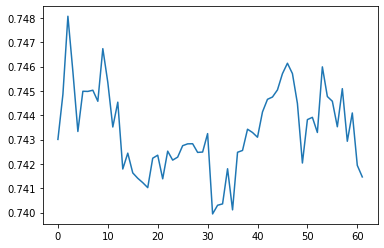

In [ ]:
plot=plt.plot(np.arange(len(history.history["val_loss"])),history.history["val_loss"])
plt.show()  

In [ ]:
results=model1.predict(train_x)

In [ ]:
model1.save("/content/drive/MyDrive/UBEM/local_data_clas_1_balanced")

INFO:tensorflow:Assets written to: /content/drive/MyDrive/UBEM/local_data_clas_1_balanced/assets


In [ ]:
true = 0
false = 0

succesfull_preds = {"0":0  , "1" :0  , "2"  :0}
unsuccesfull_preds = {"0":0  , "1" :0  , "2"  :0}

for i in range(len(test_x)):
  print(results[i])
  print( (np.where(results[i] == results[i].max()))[0] , np.where(test_y[i] == test_y[i].max())[0]   )
  print("___________________________________________")
  if len(np.where(test_y[i] == test_y[i].max())[0]) ==1   and (np.where(results[i] == results[i].max()))[0] ==  np.where(test_y[i] == test_y[i].max())[0] :
      
      true += 1
      succesfull_preds[str(np.where(test_y[i] == test_y[i].max())[0][0])] += 1
  else:

      false += 1  
      unsuccesfull_preds[str(np.where(test_y[i] == test_y[i].max())[0][0])] += 1


print("True: ",true ,"False: ",false ) 
print("True: " ,succesfull_preds  ,"False: ",unsuccesfull_preds)

[0.62327343 0.23254198 0.14418454]
[0] [1]
___________________________________________
[0.5546166  0.24954435 0.1958391 ]
[0] [0 1 2]
___________________________________________
[0.6633158  0.12352155 0.21316269]
[0] [0 1 2]
___________________________________________
[0.553491   0.2509734  0.19553559]
[0] [0]
___________________________________________
[0.85473514 0.03492307 0.1103418 ]
[0] [0]
___________________________________________
[0.56541306 0.2420829  0.19250408]
[0] [0 1 2]
___________________________________________
[0.53325164 0.26089343 0.20585491]
[0] [0 1 2]
___________________________________________
[0.5348188  0.26807168 0.1971094 ]
[0] [1]
___________________________________________
[0.5544467  0.25237367 0.19317964]
[0] [0]
___________________________________________
[0.92028654 0.03571953 0.04399393]
[0] [1]
___________________________________________
[0.89006364 0.06161659 0.04831971]
[0] [0]
___________________________________________
[0.89056325 0.06563688 0.04

In [ ]:
"""x=without_uval.index[without_uval['YEAR0'].eq(1.0)]
data_balanced = without_uval.drop(np.random.choice(without_uval.index[without_uval['YEAR0'].eq(1)], 590))
data_balanced = data_balanced.drop(np.random.choice(data_balanced.index[data_balanced['YEAR1'].eq(1)], 280))

length_2=without_uval.shape[0]

train_x2 = np.array(data_balanced.loc[0:length_2*0.7])[:,1:8].astype('float32') 
train_y2 = np.array(data_balanced.loc[0:length_2*0.7])[:,1:8].astype('float32')  
test_x2 = np.array(data_balanced.loc[length_2*0.7:])[:,8:11].astype('float32') 
test_y2 = np.array(data_balanced.loc[length_2*0.7:])[:,8:11].astype('float32')"""


In [ ]:
model2 = keras.models.Sequential()

model2.add(keras.layers.Dense(7,activation="relu"))
model2.add(keras.layers.BatchNormalization())

model2.add(keras.layers.Dense(64,activation="relu"))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Dropout(0.5))

model2.add(keras.layers.Dense(32,activation="relu"))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Dropout(0.5))

model2.add(keras.layers.Dense(3,activation="softmax"))

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.005,
    decay_steps=80,
    decay_rate=0.7)

adam = tf.keras.optimizers.Adam(learning_rate=lr_schedule,beta_1=0.9,beta_2=0.999, epsilon=1e-07  )

model2.compile(optimizer=adam, loss=keras.losses.CategoricalCrossentropy(), metrics=["accuracy",keras.metrics.AUC(multi_label=True)])

In [ ]:
arageri=keras.callbacks.EarlyStopping(monitor="val_loss", patience=15)
arageri2=keras.callbacks.EarlyStopping(monitor="loss", patience=15)
arageri3=TerminateOnBaseline(monitor="val_auc_4",baseline=0.65)

history=model2.fit(train_x2,train_y2, validation_data=(test_x2,  test_y2), epochs=500,batch_size=16,callbacks=[arageri3],verbose=1)

Epoch 1/500
9/9 [==============================] - 0s 25ms/step - loss: 0.6099 - accuracy: 0.7431 - auc_4: 0.8944 - val_loss: 1.1221 - val_accuracy: 0.5397 - val_auc_4: 0.8653


In [ ]:
results2=model2.predict(test_x)

In [ ]:
true = 0
false = 0

succesfull_preds = {"0":0  , "1" :0  , "2"  :0}
unsuccesfull_preds = {"0":0  , "1" :0  , "2"  :0}

for i in range(len(test_x)):
  print(results2[i])
  print( (np.where(results2[i] == results2[i].max()))[0] , np.where(test_y[i] == test_y[i].max())[0]   )
  print("___________________________________________")
  if len(np.where(test_y[i] == test_y[i].max())[0]) ==1   and (np.where(results2[i] == results2[i].max()))[0] ==  np.where(test_y[i] == test_y[i].max())[0] :
      
      true += 1
      succesfull_preds[str(np.where(test_y[i] == test_y[i].max())[0][0])] += 1
  else:

      false += 1  
      unsuccesfull_preds[str(np.where(test_y[i] == test_y[i].max())[0][0])] += 1


print("True: ",true ,"False: ",false ) 
print("True: " ,succesfull_preds  ,"False: ",unsuccesfull_preds)

[4.1198207e-04 1.0287400e-03 9.9855930e-01]
[2] [1]
___________________________________________
[3.6962787e-04 9.0038060e-04 9.9873000e-01]
[2] [0 1 2]
___________________________________________
[7.2557351e-04 7.0693617e-04 9.9856746e-01]
[2] [0 1 2]
___________________________________________
[9.481122e-04 2.804256e-03 9.962476e-01]
[2] [0]
___________________________________________
[0.0010615  0.00189694 0.9970415 ]
[2] [0]
___________________________________________
[0.00154811 0.00183647 0.99661547]
[2] [0 1 2]
___________________________________________
[0.00103331 0.00168117 0.9972855 ]
[2] [0 1 2]
___________________________________________
[0.00100484 0.00302717 0.995968  ]
[2] [1]
___________________________________________
[6.6935015e-04 1.4113788e-03 9.9791926e-01]
[2] [0]
___________________________________________
[0.00116019 0.00276498 0.99607486]
[2] [1]
___________________________________________
[7.1232225e-04 2.0024751e-03 9.9728525e-01]
[2] [0]
____________________